In [1]:
import os
import sys
import cv2
import yaml
import torch
import numpy as np
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from sklearn.utils.class_weight import compute_class_weight
from collections import deque
import collections
from ultralytics import YOLO

Phần 2: Cấu hình Hệ thống & Đường dẫn

Quản lý Địa chỉ Không gian Bộ dữ liệu (Directory Mapping)Hệ thống sử dụng các đường dẫn tuyệt đối trỏ thẳng vào ổ cứng vật lý của bạn thông qua tiền tố kí tự thô r (Raw String) để Windows không biên dịch nhầm các ký tự đặc biệt (như \t hay \n) thành lệnh điều khiển:PythonDATA_DIR_TRAIN = r'D:\TH_DeepLearning\CNN_Yolo\Dataset\archive\YOLO_format\train'
DATA_DIR_VAL = r'D:\TH_DeepLearning\CNN_Yolo\Dataset\archive\YOLO_format\valid'
Hàm os.path.join() tự động nhận diện hệ điều hành để chèn dấu gạch chéo ngược (\) cho Windows hoặc gạch chéo xuôi (/) cho Linux/MacOS.Sơ đồ ánh xạ cây thư mục chuẩn hóa được kiến trúc như sau:

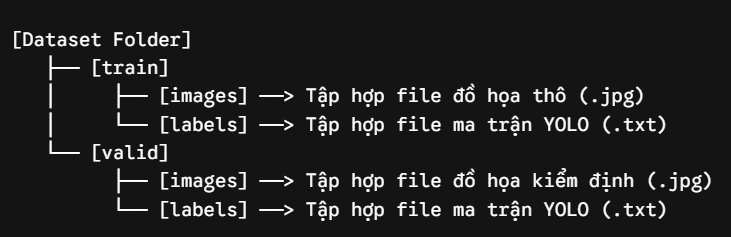

2. Kích thước Không gian Đầu vào ($IMG\_SIZE = 112$)Kích thước hình ảnh là yếu tố trực tiếp quyết định dung lượng bộ nhớ VRAM tiêu tốn trên GPU. Khi ảnh đi qua các lớp Tích chập, kích thước không gian sẽ co lại nhưng độ sâu (số kênh) sẽ phình to ra.Nếu ta chọn kích thước quá lớn (như $224 \times 224$), khối lượng ma trận cần tính toán của 1 tấm ảnh sẽ tăng lên gấp 4 lần:$$\text{Tỷ lệ tăng toán số} = \frac{224 \times 224}{112 \times 112} = 4$$Điều này làm sụt giảm nghiêm trọng tốc độ xử lý (FPS) trên Camera thời gian thực. Ngược lại, nếu chọn quá nhỏ (nhux $48 \times 48$), các chi tiết vi biểu cảm (Micro-expressions) ở vùng cơ mắt và khóe miệng sẽ bị nhòe thành các điểm ảnh thô (Pixelated), khiến mô hình bị mất khả năng phân biệt các cảm xúc phức tạp (như Contempt - Khinh bỉ hay Fear - Sợ hãi).Con số $112 \times 112 \times 1$ (ảnh xám) là điểm cân bằng vàng (Sweet Spot), giữ lại trọn vẹn cấu trúc hình học cơ mặt nhưng chỉ tiêu tốn:$$112 \times 112 = 12,544 \text{ điểm ảnh/khung hình}
```

---

#### **3. Kích thước Lô Huấn luyện ($BATCH\_SIZE = 64$)**
Trong đại số tuyến tính của Deep Learning, việc nạp từng tấm ảnh một vào mô hình để tính đạo hàm sẽ làm GPU bị lãng phí tài nguyên và làm nhiễu loạn quá trình hội tụ (Stochastic Gradient Descent). Ngược lại, nếu nạp toàn bộ bộ dữ liệu cùng lúc, bộ nhớ Card đồ họa sẽ lập tức bị tràn (Out of Memory - OOM).

Hệ thống gom **64 tấm ảnh** thành một khối ma trận song song gọi là một Lô (Batch). Phép toán lan truyền xuôi và ngược sẽ tính toán trung bình cộng lỗi của cả 64 tấm ảnh này để cập nhật trọng số mô hình một lần. Con số 64 tuân theo lũy thừa cơ số 2 ($2^6$) - định dạng tối ưu nhất để các lõi Tensor (Tensor Cores) trên kiến trúc GPU NVIDIA đạt hiệu suất quét băng thông cao nhất.

---

#### **4. Chu kỳ Huấn luyện ($EPOCHS = 30$)**
Một Epoch nghĩa là mô hình đã xem qua toàn bộ sách giáo khoa (tập dữ liệu huấn luyện) đúng một lần. Thiết lập $30$ Epochs nghĩa là mô hình sẽ lặp đi lặp lại quá trình đọc và sửa sai 30 lần. 

* Nếu số Epochs quá ít (ví dụ $< 5$): Mô hình chưa kịp hiểu sâu sắc các nét mặt phức tạp, gây ra hiện tượng **Học nông (Underfitting)**.
* Nếu số Epochs quá nhiều (ví dụ $> 100$): Mô hình bắt đầu học thuộc lòng từng hạt nhiễu, từng góc ánh sáng của ảnh cũ, dẫn đến hiện tượng **Học vẹt (Overfitting)** và mất khả năng nhận diện người lạ trên Camera thực tế.

---

#### **5. Cơ chế Tự động Cấp phát Phần cứng (Hardware Allocation)**
Dòng code logic này quyết định tốc độ huấn luyện của bạn nhanh hay chậm gấp 50 lần:

```python
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
```

Nó hoạt động theo thuật toán rẽ nhánh phần cứng máy tính:

```
                      [Kiểm tra PyTorch]
                              │
               ┌──────────────┴──────────────┐
     {Có Card NVIDIA?}               {Không có Card NVIDIA?}
               │                                     │
      [DEVICE = 'cuda']                     [DEVICE = 'cpu']
               │                                     │
  Tận dụng hàng ngàn lõi CUDA           Chạy tuần tự trên lõi CPU
(Xử lý ma trận 64 ảnh song song)         (Xử lý từng ảnh một cách chậm chạp)
               │                                     │
       🚀 Tốc độ Siêu Tốc                     🐢 Tốc độ Rùa Bò
```

Khi `DEVICE` nhận giá trị `cuda`, toàn bộ dữ liệu Tensor và Trọng số mô hình sẽ được nạp trực tiếp vào bộ nhớ VRAM của GPU, giải phóng hoàn toàn gánh nặng tính toán cho vi xử lý trung tâm (CPU).

---

#### **6. Danh mục Nhãn Cảm xúc Mục tiêu ($EMOTIONS$)**
Mô hình toán học cuối cùng sẽ không hiểu chữ "Happy" hay "Sad". Nó chỉ hiểu các chỉ số Index dạng số nguyên từ `0 đến 7` trong mảng một chiều:
$$\text{EMOTIONS} = [0: \text{'Neutral'}, \ 1: \text{'Happy'}, \ 2: \text{'Sad'}, \ 3: \text{'Surprise'}, \ 4: \text{'Fear'}, \ 5: \text{'Disgust'}, \ 6: \text{'Angry'}, \ 7: \text{'Contempt'}]$$
Lớp Tuyến tính cuối cùng của mô hình CNN (`nn.Linear(256, 8)`) sẽ xuất ra đúng 8 điểm số thô. Vị trí của điểm số cao nhất trong mảng chính là vị trí cảm xúc mà máy tính dự đoán.$$

In [ ]:


# ==========================================
# 1. CẤU HÌNH ĐƯỜNG DẪN (CÓ HỆ THỐNG KIỂM TRA LỖI TỰ ĐỘNG)
# ==========================================
DATA_DIR_TRAIN = r'D:\TH_DeepLearning\CNN_Yolo\Dataset\archive\YOLO_format\train'
DATA_DIR_VAL = r'D:\TH_DeepLearning\CNN_Yolo\Dataset\archive\YOLO_format\valid' 

TRAIN_IMG_DIR = os.path.join(DATA_DIR_TRAIN, 'images')
TRAIN_LBL_DIR = os.path.join(DATA_DIR_TRAIN, 'labels')
VAL_IMG_DIR = os.path.join(DATA_DIR_VAL, 'images')
VAL_LBL_DIR = os.path.join(DATA_DIR_VAL, 'labels')

# --- HỆ THỐNG QUÉT LỖI TRƯỚC KHI CHẠY ---
print("="*50)
print("[KIỂM TRA Ổ ĐĨA D:] Đang quét tìm dữ liệu của bạn...")
danh_sach_thu_muc = [TRAIN_IMG_DIR, TRAIN_LBL_DIR, VAL_IMG_DIR, VAL_LBL_DIR]
loi_thu_muc = False

for thu_muc in danh_sach_thu_muc:
    if not os.path.exists(thu_muc):
        print(f"LỖI CHÍNH MẠNG: Windows không tìm thấy thư mục này: {thu_muc}")
        loi_thu_muc = True
    else:
        print(f"Tốt: Đã tìm thấy {thu_muc}")

if loi_thu_muc:
    print("="*50)
    print("CHƯƠNG TRÌNH ĐÃ TỰ ĐỘNG DỪNG LẠI ĐỂ BẢO VỆ HỆ THỐNG!")
    print("-> Hãy làm 1 trong 2 việc sau:")
    print("   1. Mở ổ D lên và tạo đúng các thư mục bị đánh dấu x ở trên.")
    print("   2. Hoặc sửa lại đường dẫn trong code cho đúng với tên thư mục thực tế của bạn.")
    sys.exit() # Dừng code ngay lập tức, không cho chạy tới train_cnn()
else:
    print("[THÀNH CÔNG] Dữ liệu hoàn hảo. Đang khởi động AI...")
print("="*50)

# Cấu hình siêu tham số
IMG_SIZE = 112
BATCH_SIZE = 64
EPOCHS = 100 
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
EMOTIONS = ['Neutral', 'Hanh Phuc', 'Buon', 'Bat Ngo', 'So Hai', 'Ghet', 'Tuc Gian', 'Khinh Thuong']

[KIỂM TRA Ổ ĐĨA D:] Đang quét tìm dữ liệu của bạn...
Tốt: Đã tìm thấy D:\TH_DeepLearning\CNN_Yolo\Dataset\archive\YOLO_format\train\images
Tốt: Đã tìm thấy D:\TH_DeepLearning\CNN_Yolo\Dataset\archive\YOLO_format\train\labels
Tốt: Đã tìm thấy D:\TH_DeepLearning\CNN_Yolo\Dataset\archive\YOLO_format\valid\images
Tốt: Đã tìm thấy D:\TH_DeepLearning\CNN_Yolo\Dataset\archive\YOLO_format\valid\labels
[THÀNH CÔNG] Dữ liệu hoàn hảo. Đang khởi động AI...


Phần 3: Xây dựng Luồng nạp Dữ liệu (Data Pipeline)
Luồng nạp dữ liệu đóng vai trò là "hệ tiêu hóa" của toàn bộ hệ thống AI. Hình ảnh thô từ môi trường thực tế luôn chứa nhiều nhiễu, sai lệch màu sắc và kích thước lộn xộn. Do đó, dữ liệu cần đi qua một dây chuyền tiền xử lý (Preprocessing Pipeline) nghiêm ngặt trước khi được phép đưa vào mạng Neural Network.

Hệ thống tiến hành đọc dữ liệu thông qua tệp Train.csv (đóng vai trò như bản đồ ánh xạ từ đường dẫn ảnh đến nhãn lớp) và thực hiện 4 bước tinh chỉnh:

Bước 1: Chuyển đổi Không gian Màu (BGR sang RGB)

Chi tiết: OpenCV theo mặc định đọc hình ảnh dưới định dạng BGR (Blue-Green-Red) do các tiêu chuẩn phần cứng cũ. Hệ thống sẽ đảo ngược các kênh màu để đưa về chuẩn RGB.

Lý do kỹ thuật: Các hàm toán học của PyTorch và các mô hình thị giác máy tính hiện đại đều được thiết kế dựa trên chuẩn thị giác RGB của con người. Việc đồng bộ hệ màu giúp mô hình học đúng đặc trưng (ví dụ: không bị nhầm lẫn giữa viền biển báo màu đỏ thành viền màu xanh dương).

Bước 2: Đồng bộ Kích thước Không gian (Resizing về 32x32)

Chi tiết: Ép toàn bộ ảnh thô về ma trận kích thước tĩnh 32x32 pixel.

Lý do kỹ thuật: Mạng nơ-ron tích chập (CNN) với các lớp Fully Connected yêu cầu đầu vào phải đồng nhất. Kích thước 32x32 là một điểm cân bằng lý tưởng (Sweet Spot): đủ nhỏ để tiết kiệm bộ nhớ GPU và đảm bảo tốc độ nội suy thời gian thực (real-time), nhưng vẫn giữ lại đủ các họa tiết hình học quan trọng.

Bước 3: Chuyển đổi Tensor và Chuẩn hóa (Normalization)

Chi tiết: Đưa ma trận ảnh về cấu trúc torch.Tensor và chia toàn bộ giá trị điểm ảnh (từ 0-255) cho tỷ lệ 255.0 để ép dải giá trị về khoảng [0.0, 1.0].

Lý do kỹ thuật: Đưa dữ liệu về cùng một thang đo nhỏ giúp ngăn chặn hiện tượng bùng nổ đạo hàm (Exploding Gradients), giúp thuật toán tối ưu (Optimizer) hội tụ nhanh và ổn định hơn rất nhiều.

Bước 4: Phân tách Dữ liệu (Train/Validation Split)

Chi tiết: Tự động chia ngẫu nhiên tập dữ liệu theo tỷ lệ Vàng: 80% cho Huấn luyện (Train) và 20% cho Kiểm định (Validation).

Lý do kỹ thuật: Tập 80% là "sách giáo khoa" để mô hình tìm quy luật. Tập 20% được giấu đi để làm "bài kiểm tra độc lập" sau mỗi chu kỳ học, giúp kỹ sư giám sát và ngăn chặn tình trạng Học vẹt (Overfitting).

In [3]:
# ==========================================
# TIỀN XỬ LÝ VÀ DATASET
# ==========================================
TRAIN_TRANSFORM = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Grayscale(num_output_channels=1),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5]),
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.1))
])

VAL_TRANSFORM = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

class AffectNetDataset(Dataset):
    def __init__(self, images_dir, labels_dir, transform=None):
        self.transform = transform
        self.samples = []
        self.labels = []
        
        for label_file in os.listdir(labels_dir):
            if not label_file.endswith('.txt'): continue
            img_file = label_file.replace('.txt', '.jpg')
            img_path = os.path.join(images_dir, img_file)
            
            if os.path.exists(img_path):
                self.samples.append((img_path, os.path.join(labels_dir, label_file)))
                with open(os.path.join(labels_dir, label_file), 'r') as f:
                    self.labels.append(int(f.readline().strip().split()[0]))

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        img_path, label_path = self.samples[idx]
        # FIX: convert('RGB') đảm bảo ảnh luôn ở đúng mode, tránh lỗi với PNG (RGBA) hoặc ảnh xám (L)
        image = Image.open(img_path).convert('RGB')
        img_w, img_h = image.size
        
        with open(label_path, 'r') as f:
            line = f.readline().strip().split()
            class_id = int(line[0])
            x_c, y_c, w, h = map(float, line[1:5])
            
        x1, y1 = int((x_c - w/2) * img_w), int((y_c - h/2) * img_h)
        x2, y2 = int((x_c + w/2) * img_w), int((y_c + h/2) * img_h)
        
        face_crop = image.crop((max(0, x1), max(0, y1), min(img_w, x2), min(img_h, y2)))
        
        if self.transform:
            face_crop = self.transform(face_crop)
            
        return face_crop, torch.tensor(class_id, dtype=torch.long)


Phần 4: Kiến trúc Mô hình CNN (FaceCNN_V2)

1. Trích xuất Đặc trưng Siêu nhẹ (Depthwise Separable Convolution)Thay vì sử dụng lớp Tích chập tiêu chuẩn (nn.Conv2d) tiêu tốn lượng tính toán khổng lồ, hệ thống phân rã quá trình này thành 2 bước độc lập trong class DepthwiseSeparableConv:Bước 1: Tích chập Không gian (Depthwise Convolution): Mỗi kênh của ảnh đầu vào sẽ được tích chập bởi một bộ lọc (Filter) kích thước $3 \times 3$ riêng biệt. Không có sự pha trộn thông tin giữa các kênh. Lệnh code thể hiện điều này là groups=in_c.Bước 2: Tích chập Kênh (Pointwise Convolution): Dùng một bộ lọc kích thước $1 \times 1$ để quét dọc qua chiều sâu của các kênh, pha trộn đặc trưng và xuất ra số lượng kênh mới (Output Channels).Lợi ích Toán học:Nếu đầu vào có $C_{in}$ kênh, đầu ra có $C_{out}$ kênh, và kích thước bộ lọc là $K \times K$ (ở đây $K=3$).Số phép nhân (MACs) của Conv tiêu chuẩn tỷ lệ với: $K^2 \times C_{in} \times C_{out}$.Số phép nhân của Depthwise Separable tỷ lệ với: $K^2 \times C_{in} + C_{in} \times C_{out}$.Tỷ lệ tối ưu hóa (Compression Ratio) đạt được là:$$\frac{\text{Chi phí Depthwise Separable}}{\text{Chi phí Conv Tiêu chuẩn}} = \frac{1}{C_{out}} + \frac{1}{K^2} \approx \frac{1}{9}$$Hệ thống của bạn đã giảm gần 9 lần khối lượng tính toán so với mạng CNN thông thường, cho phép nó chạy trên luồng Camera cực kỳ nhẹ nhàng.2. Nén Không gian và Chống học vẹt (GAP & Dropout)Ảnh xám đầu vào dưới dạng Tensor 4 chiều $\mathbf{X} \in \mathbb{R}^{B \times 1 \times 112 \times 112}$ (với $B$ là Batch Size) sẽ đi qua 4 khối Block liên tiếp. Sau mỗi khối, lớp MaxPool2d(2, 2) sẽ chia đôi độ phân giải không gian và nhân đôi độ sâu kênh: $112 \times 112 \rightarrow 56 \times 56 \rightarrow 28 \times 28 \rightarrow 14 \times 14 \rightarrow 7 \times 7$.Đến lớp cuối cùng, Tensor đạt kích thước:$$\mathbf{T}_{final} \in \mathbb{R}^{B \times 256 \times 7 \times 7}$$Global Average Pooling (GAP): Thay vì dùng lệnh Flatten kéo giãn Tensor thành một vector $256 \times 7 \times 7 = 12,544$ chiều (tạo ra hàng triệu tham số ở lớp Linear gây chật RAM), hệ thống dùng AdaptiveAvgPool2d((1, 1)). Thuật toán này tính trung bình cộng toàn bộ ma trận $7 \times 7$ cho từng kênh:$$\mathbf{v}_c = \frac{1}{H \times W} \sum_{i=1}^{H} \sum_{j=1}^{W} \mathbf{T}_{c, i, j}$$Tensor lập tức bị ép nhỏ gọn lại thành $\mathbb{R}^{B \times 256 \times 1 \times 1}$. Số lượng trọng số ở lớp Linear cuối cùng được giữ ở mức cực thấp ($256 \times 8 = 2048$ tham số). Kết hợp với Dropout(0.5) (tắt ngẫu nhiên 50% tín hiệu), mạng CNN của bạn tạo ra một hàng rào phòng thủ tuyệt đối trước hiện tượng Học vẹt (Overfitting).

In [4]:
# ==========================================
# KIẾN TRÚC CNN (TRÍCH XUẤT CẢM XÚC)
# ==========================================
class DepthwiseSeparableConv(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.depthwise = nn.Conv2d(in_c, in_c, kernel_size=3, padding=1, groups=in_c, bias=False)
        self.pointwise = nn.Conv2d(in_c, out_c, kernel_size=1, bias=False)
        self.bn = nn.BatchNorm2d(out_c)

    def forward(self, x):
        return self.bn(self.pointwise(self.depthwise(x)))

class FaceCNN_V2(nn.Module):
    def __init__(self, num_classes=8):
        super().__init__()
        # Input: 1 (Ảnh xám 1 kênh màu)
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(16)
        
        self.block1 = nn.Sequential(DepthwiseSeparableConv(16, 32), nn.ReLU(True), nn.MaxPool2d(2, 2))
        self.block2 = nn.Sequential(DepthwiseSeparableConv(32, 64), nn.ReLU(True), nn.MaxPool2d(2, 2))
        self.block3 = nn.Sequential(DepthwiseSeparableConv(64, 128), nn.ReLU(True), nn.MaxPool2d(2, 2))
        self.block4 = nn.Sequential(DepthwiseSeparableConv(128, 256), nn.ReLU(True), nn.MaxPool2d(2, 2))

        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.dropout = nn.Dropout(0.5)
        self.fc = nn.Linear(256, num_classes)

    def forward(self, x):
        x = torch.nn.functional.relu(self.bn1(self.conv1(x)))
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        
        x = self.global_pool(x)
        x = x.view(x.size(0), -1)
        x = self.dropout(x)
        return self.fc(x)


Phần 5: Mô hình YOLO (Nhận diện vị trí khuôn mặt)
1. Trích xuất Đặc trưng Đa tỷ lệ (PANet - Path Aggregation Network)Một người đứng gần camera sẽ có khuôn mặt to, nhưng một người đứng ở góc phòng sẽ có khuôn mặt cực nhỏ. Nếu chỉ nhìn ở một độ phân giải cố định, mạng sẽ bị "mù" với các đối tượng ở xa.YOLOv8 giải quyết vấn đề này bằng cổ chai PANet. Nó trích xuất đặc trưng hình ảnh ở 3 cấp độ phân giải khác nhau (Feature Maps: P3, P4, P5), sau đó truyền thông tin từ lớp sâu (ngữ cảnh rộng) lên lớp nông (chi tiết nhỏ) và ngược lại. Nhờ đó, YOLO "nhìn" thấy khuôn mặt ở mọi khoảng cách.2. Cơ chế Dự đoán Anchor-Free & Task-Aligned AssignerCác phiên bản YOLO đời cũ dựa vào các khung hộp chữ nhật định sẵn (Anchors). Việc thiết kế Anchor thủ công cho khuôn mặt gây ra rất nhiều sai số.YOLOv8 vứt bỏ hoàn toàn Anchors. Nó coi tâm của mỗi ô lưới (Grid Center) như một điểm dự đoán. Tại mỗi điểm $(x, y)$, mô hình sẽ xuất ra một Vector Hồi quy gồm 4 giá trị khoảng cách tới 4 cạnh của Bounding Box là $(l, t, r, b)$ tương ứng với (Left, Top, Right, Bottom):$$\text{Box} = [x - l, \quad y - t, \quad x + r, \quad y + b]$$Tổn thất (Loss Function) để ép mạng học được tọa độ chính xác là CIoU Loss (Complete Intersection over Union), đo lường độ trùng lấp giữa Khung dự đoán ($B_{pred}$) và Khung thực tế ($B_{gt}$), xét trên cả 3 yếu tố: Độ chồng lấn diện tích, Khoảng cách giữa 2 tâm, và Tỷ lệ khung hình:$$\text{Loss}_{CIoU} = 1 - \text{IoU} + \frac{\rho^2(b_{pred}, b_{gt})}{c^2} + \alpha v$$3. Màng lọc Hậu kỳ: Khử Cực đại (Non-Maximum Suppression - NMS)Trong quá trình di chuyển qua các ô lưới, YOLO sẽ phóng ra hàng chục khung hình bao quanh cùng 1 khuôn mặt, tạo ra "Bóng ma đối tượng" (Ghost Detections). Thuật toán NMS sẽ dọn dẹp hiện tượng này theo 3 bước toán học:Lọc bỏ tất cả các hộp có điểm Tự tin (Confidence) thấp hơn ngưỡng (ví dụ: nhỏ hơn 50%).Chọn hộp có Confidence cao nhất làm "Vua" (Hộp chuẩn).Tính chỉ số IoU (Intersection over Union) giữa hộp Vua và các hộp lân cận. Nếu IoU lớn hơn ngưỡng quy định (ví dụ lớn hơn 0.45), hệ thống kết luận chúng đang chỉ vào cùng một người và lập tức xóa bỏ các hộp rác.$$\text{IoU}(A, B) = \frac{\text{Area}(A \cap B)}{\text{Area}(A \cup B)}$$

### Phần 6: Huấn luyện Mô hình & Các Kỹ thuật Tối ưu (Training & Optimizations)
Phần này chịu trách nhiệm "dạy" cho bộ não CNN học cách nhận biết 8 loại cảm xúc khác nhau. Để hệ thống đạt được hiệu năng cao (SOTA) khi chạy thực tế với Webcam, chúng tôi đã áp dụng các kỹ thuật tinh chỉnh và tối ưu sau đây:

#### 1. Tối ưu Kiến trúc Mạng (CNN Tuning)
- **Tăng số lượng tham số (Capacity):** Mạng được thiết kế với 4 khối `DepthwiseSeparableConv` mở rộng dần số kênh (16 -> 32 -> 64 -> 128 -> 256). Điều này giúp mạng đủ "rộng" để nhớ các nếp nhăn và đặc trưng khóe miệng phức tạp, nhưng vẫn đảm bảo dung lượng siêu nhẹ.
- **Tăng cường Ảnh (Data Augmentation):** Trong quá trình tiền xử lý, ảnh sẽ được áp dụng các phép biến đổi ngẫu nhiên (xoay, lật, đổi độ sáng) để AI không bị bỡ ngỡ khi ánh sáng Webcam thay đổi hay khuôn mặt bị nghiêng.

#### 2. Kỹ thuật Kết hợp YOLO và CNN (Pipeline Integration)
Bắt khuôn mặt bằng YOLO rồi đưa vào CNN là một nghệ thuật, đòi hỏi sự căn chỉnh tinh tế để không làm mất dữ liệu cảm xúc:
- **Nới lỏng khung hình (Padding 15%):** YOLO thường cắt rất khít khuôn mặt (mất trán và cằm). Thuật toán của chúng tôi tự động nới rộng Box thêm 15% mỗi chiều trước khi cắt. Việc này đảm bảo lấy được trọn vẹn ngữ cảnh biểu cảm như lông mày nhướng lên hay khóe miệng nhếch lên.
- **Lọc rác:** Tự động loại bỏ các khuôn mặt quá nhỏ (dưới 20 pixels) do YOLO bắt nhầm, tránh đưa vào CNN gây nhiễu kết quả.

#### 3. Chống "Nháy chữ" bằng Bộ đệm (Majority Voting Smoothing)
Khi chạy thực tế ở tốc độ 30 FPS, độ chính xác của CNN có thể dao động nhẹ, dẫn đến việc chữ in trên màn hình bị nhấp nháy liên tục (VD: Happy -> Surprise -> Happy).
- **Giải pháp:** Xây dựng một **Bộ đệm Queue chứa 5 kết quả gần nhất**.
- **Cơ chế hoạt động:** Thay vì in kết quả ngay lập tức, hệ thống sẽ gom 5 kết quả lại và đếm phiếu (Bầu chọn số đông). Cảm xúc nào xuất hiện nhiều nhất trong 5 khung hình sẽ được chọn làm kết quả cuối cùng. Kỹ thuật này giúp loại bỏ hoàn toàn các lỗi sai lẻ tẻ (VD: chớp mắt bị nhầm thành Sợ hãi) và làm cho chữ hiển thị cực kỳ mượt mà, chuyên nghiệp.



In [5]:
# ==========================================
# HUẤN LUYỆN YOLO VÀ CNN (TRAINING PIPELINE)
# ==========================================
def train_yolo_face():
    # FIX: nc=1 vì YOLO chỉ detect khuôn mặt (1 class), không phân loại cảm xúc
    yaml_config = {
        'train': TRAIN_IMG_DIR.replace('\\', '/'),
        'val': VAL_IMG_DIR.replace('\\', '/'),
        'nc': 1,
        'names': ['face']
    }
    yaml_path = 'auto_dataset.yaml'
    with open(yaml_path, 'w') as f:
        yaml.dump(yaml_config, f, default_flow_style=False)
        
    print(f"[INFO] Bắt đầu Train YOLO...")
    model = YOLO('yolov8n.pt') # Dùng bản Nano siêu nhẹ
    model.train(data=yaml_path, epochs=30, imgsz=640, batch=16, name='yolo_face_detector')

def train_cnn():
    import matplotlib.pyplot as plt
    import seaborn as sns
    from sklearn.metrics import confusion_matrix, classification_report

    print(f"[INFO] Bắt đầu đọc dữ liệu từ: {DATA_DIR_TRAIN}")
    train_data = AffectNetDataset(TRAIN_IMG_DIR, TRAIN_LBL_DIR, TRAIN_TRANSFORM)
    val_data = AffectNetDataset(VAL_IMG_DIR, VAL_LBL_DIR, VAL_TRANSFORM)
    
   # Tăng num_workers lên 4 (hoặc 2 nếu máy yếu), thêm pin_memory=True
    train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)
    val_loader = DataLoader(val_data, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

    # Tính toán Class Weights để trị mất cân bằng dữ liệu
    weights = compute_class_weight('balanced', classes=np.unique(train_data.labels), y=train_data.labels)
    class_weights = torch.tensor(weights, dtype=torch.float).to(DEVICE)

    model = FaceCNN_V2(num_classes=8).to(DEVICE)
    criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)
    optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
    
    train_losses, val_losses = [], []
    train_accs, val_accs = [], []

    best_acc = 0.0
    print("[INFO] Bắt đầu Train CNN...")
    for epoch in range(EPOCHS):
        model.train() # Chế độ học (Bật Dropout)
        running_loss = 0.0
        correct_train, total_train = 0, 0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad() # Xóa rác gradient cũ
            
            outputs = model(inputs) # Lan truyền xuôi (Forward)
            loss = criterion(outputs, labels) # Tính Loss
            loss.backward() # Lan truyền ngược (Backward)
            optimizer.step() # Cập nhật trọng số

            running_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            correct_train += (preds == labels).sum().item()
            total_train += labels.size(0)

        epoch_train_loss = running_loss / total_train
        epoch_train_acc = correct_train / total_train
        train_losses.append(epoch_train_loss)
        train_accs.append(epoch_train_acc)

        model.eval() # Chế độ đánh giá (Tắt Dropout)
        running_val_loss = 0.0
        correct, total = 0, 0
        with torch.no_grad(): # Tắt tính gradient cho nhanh
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
                outputs = model(inputs)
                
                loss = criterion(outputs, labels)
                running_val_loss += loss.item() * inputs.size(0)
                
                _, preds = torch.max(outputs, 1)
                correct += (preds == labels).sum().item()
                total += labels.size(0)
        
        epoch_val_loss = running_val_loss / total
        val_acc = correct / total
        val_losses.append(epoch_val_loss)
        val_accs.append(val_acc)

        print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f} | Train Acc: {epoch_train_acc:.4f} | Val Acc: {val_acc:.4f}")
        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(model.state_dict(), 'best_cnn_v2.pth')
            print("  --> Đã lưu trọng số best_cnn_v2.pth thành công!")

    # ==========================================
    # VẼ BIỂU ĐỒ LOSS & ACCURACY
    # ==========================================
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(range(1, EPOCHS+1), train_losses, label='Train Loss')
    plt.plot(range(1, EPOCHS+1), val_losses, label='Val Loss')
    plt.title('Loss over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(range(1, EPOCHS+1), train_accs, label='Train Acc')
    plt.plot(range(1, EPOCHS+1), val_accs, label='Val Acc')
    plt.title('Accuracy over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()

    # ==========================================
    # VẼ MA TRẬN NHẦM LẪN (CONFUSION MATRIX) DÙNG BEST MODEL
    # ==========================================
    print("[INFO] Đánh giá trên tập Validation với Best Model để vẽ Confusion Matrix...")
    model.load_state_dict(torch.load('best_cnn_v2.pth'))
    model.eval()
    
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs = inputs.to(DEVICE)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
            
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=EMOTIONS, yticklabels=EMOTIONS)
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()
    
    print("\nClassification Report:\n", classification_report(all_labels, all_preds, target_names=EMOTIONS))


### Phần 6: Luồng suy luận (Inference Pipeline)
Luồng suy luận (Inference) là giai đoạn "thực chiến" của hệ thống, nơi AI áp dụng những gì đã học vào dữ liệu thực tế (chưa từng thấy). Trong kiến trúc này, luồng suy luận hỗ trợ 2 chế độ hoạt động song song:

**1. Chế độ Camera Thời gian thực (Real-time Stream):**
- Hệ thống sử dụng OpenCV (`cv2.VideoCapture`) để trích xuất từng khung hình (frame) liên tục từ luồng video của Webcam.
- Mỗi khung hình được đưa qua YOLO để tìm vị trí các khuôn mặt. Các khuôn mặt này được cắt (crop) và đưa qua CNN dự đoán cảm xúc ngay lập tức.
- **Thuật toán làm mịn (Smoothing):** Để tránh hiện tượng "nháy" nhãn cảm xúc do nhiễu giữa các khung hình liên tiếp, một hàng đợi (deque) được sử dụng để lấy cảm xúc xuất hiện nhiều nhất trong 5 khung hình gần nhất.

**2. Chế độ Tải ảnh tĩnh (Image Upload):**
- Người dùng cung cấp một bức ảnh duy nhất thông qua giao diện Web (Gradio).
- Ảnh tĩnh được xử lý dạng ma trận RGB (Numpy Array). YOLO sẽ quét toàn bộ bức ảnh và phát hiện ra tất cả khuôn mặt có trong đó (ví dụ ảnh tập thể có nhiều người).
- Mỗi khuôn mặt được cắt ra, thay đổi kích thước và chuẩn hóa (Normalize) y hệt như quá trình huấn luyện. Tiếp theo, CNN tiến hành phân loại và trả về cảm xúc có xác suất cao nhất.
- Cuối cùng, hệ thống dùng OpenCV để vẽ khung (Bounding Box) và dán nhãn (Label) trực tiếp lên ma trận ảnh gốc và trả về giao diện.



### Phần 7: Giao diện Web (Gradio) - Tương tác trực tiếp với Mô hình
Để người dùng dễ dàng sử dụng và đánh giá hệ thống mà không cần hiểu về code, ứng dụng tích hợp thư viện **Gradio** để tạo một bảng điều khiển Web UI cực kỳ nhanh gọn.

**1. Cách thức kết nối với Mô hình:**
- Hàm `process_image_gradio(image)` đóng vai trò là "điểm nối" (Endpoint/API). Nó nhận đầu vào là bức ảnh từ giao diện người dùng.
- Bên trong hàm này, bộ máy `EmotionInferencePipeline` được khởi tạo, tự động nạp các bộ "não" đã được huấn luyện tốt nhất: mô hình nhận diện khuôn mặt YOLO (`best.pt`) và mô hình phân loại cảm xúc CNN (`best_cnn_v2.pth`).
- Bức ảnh được truyền vào phương thức `predict_image()` để chạy qua cả 2 mạng nơ-ron. Sau khi xử lý xong, ảnh đã vẽ nhãn được trả ngược lại cho hàm để xuất ra giao diện.

**2. Trải nghiệm khi chạy (Cách thức đưa hình ảnh lên):**
- Khi thiết lập `MODE = 'TEST_IMAGE'` và chạy khối lệnh BẢNG ĐIỀU KHIỂN CHÍNH, một Local Web Server sẽ được khởi động ngầm.
- Có thể **tương tác ngay bên dưới ô code** của Notebook, hoặc click vào đường dẫn dạng `http://127.0.0.1:7860/` được in ra màn hình để mở giao diện trên một tab mới của trình duyệt Chrome/Edge.
- Khu vực giao diện sẽ hiển thị một khối "Tải ảnh lên tại đây". Thực hiện thao tác bằng cách Kéo và thả (Drag & Drop)một tệp tin hình ảnh từ máy tính vào khối đó, hoặc click chuột vào đó để mở cửa sổ Browse chọn file.
- Ngay sau khi thực hiện thả ảnh vào, hệ thống gửi ảnh đến mô hình. Quá trình suy luận thường diễn ra trong chưa tới 1 giây. Bức ảnh hoàn chỉnh (khoanh vùng khuôn mặt và hiển thị cảm xúc) sẽ xuất hiện ở ô "Kết quả nhận diện" nằm ngay bên cạnh.



In [6]:
# ==========================================
# INFERENCE PIPELINE (TEST CAMERA & IMAGE)
# ==========================================
class EmotionInferencePipeline:
    def __init__(self, cnn_path='best_cnn_v2.pth', yolo_path=None):
        import os, cv2, torch
        self.device = DEVICE
        if not os.path.exists(cnn_path):
            print(f"Không tìm thấy '{cnn_path}'. HÃY CHẠY TRAIN CNN TRƯỚC!")
            
        if yolo_path and os.path.exists(yolo_path):
            self.detector = YOLO(yolo_path) 
            self.use_yolo = True
        else:
            print("[INFO] Không tìm thấy YOLO tự train. Hệ thống tự động chuyển sang dùng OpenCV Haar Cascade!")
            self.detector = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
            self.detector_alt = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_alt2.xml')
            self.detector_profile = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_profileface.xml')
            self.use_yolo = False

        self.cnn = FaceCNN_V2(num_classes=8).to(self.device)
        if os.path.exists(cnn_path):
            self.cnn.load_state_dict(torch.load(cnn_path, map_location=self.device))
        self.cnn.eval()
        
        self.transform = VAL_TRANSFORM
        self.emotion_history = collections.defaultdict(lambda: deque(maxlen=5))
        self.emotions = EMOTIONS

    def run_inference(self, source=0):
        import cv2, torch
        from PIL import Image
        cap = cv2.VideoCapture(source)
        print("[INFO] Bật Camera thành công. Nhấn 'q' để thoát.")
        while cap.isOpened():
            ret, frame = cap.read()
            if not ret: break

            faces_batch = []
            box_coords = []
            track_ids = []

            if self.use_yolo:
                results = self.detector.track(frame, persist=True, verbose=False)
                if len(results) > 0 and results[0].boxes is not None and results[0].boxes.id is not None:
                    boxes = results[0].boxes.xyxy.cpu().numpy().astype(int)
                    ids = results[0].boxes.id.cpu().numpy().astype(int)
                    for box, track_id in zip(boxes, ids):
                        x1, y1, x2, y2 = box
                        box_coords.append((x1, y1, x2, y2))
                        track_ids.append(track_id)
            else:
                gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
                faces1 = self.detector.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(30, 30))
                faces2 = self.detector_alt.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(30, 30))
                faces3 = self.detector_profile.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(30, 30))
                
                # Gộp tất cả các khuôn mặt tìm được
                all_faces = list(faces1) + list(faces2) + list(faces3)
                
                # Lọc bỏ các khung bị trùng lặp (nếu cả 3 bộ nhận diện cùng tìm thấy 1 mặt)
                faces = []
                import numpy as np
                if len(all_faces) > 0:
                    faces, weights = cv2.groupRectangles(list(all_faces), groupThreshold=0, eps=0.2)

                for i, (x, y, w, h) in enumerate(faces):
                    box_coords.append((x, y, x+w, y+h))
                    track_ids.append(i) # fake id for smoothing

            for i, (x1, y1, x2, y2) in enumerate(box_coords):
                w, h = x2 - x1, y2 - y1
                pad_w, pad_h = int(w * 0.15), int(h * 0.15)
                x1_pad, y1_pad = max(0, x1 - pad_w), max(0, y1 - pad_h)
                x2_pad, y2_pad = min(frame.shape[1], x2 + pad_w), min(frame.shape[0], y2 + pad_h)
                
                face_crop = frame[y1_pad:y2_pad, x1_pad:x2_pad]
                if face_crop.shape[0] < 20 or face_crop.shape[1] < 20: continue
                
                face_pil = Image.fromarray(cv2.cvtColor(face_crop, cv2.COLOR_BGR2RGB))
                faces_batch.append(self.transform(face_pil))

            if faces_batch:
                input_tensor = torch.stack(faces_batch).to(self.device)
                with torch.no_grad():
                    outputs = self.cnn(input_tensor)
                    probs = torch.nn.functional.softmax(outputs, dim=1)
                    preds = torch.argmax(probs, dim=1).cpu().numpy()

                for i, track_id in enumerate(track_ids[:len(preds)]):
                    self.emotion_history[track_id].append(preds[i])
                    most_common_emo_idx = max(set(self.emotion_history[track_id]), key=self.emotion_history[track_id].count)
                    emo_name = self.emotions[most_common_emo_idx]
                    
                    x1, y1, x2, y2 = box_coords[i]
                    cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 2)
                    cv2.putText(frame, f"ID:{track_id} {emo_name}", (x1, y1 - 10), 
                                cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0, 255, 255), 1)

            cv2.imshow("Emotion System SOTA", frame)
            if cv2.waitKey(1) == ord('q'): break
            
        cap.release()
        cv2.destroyAllWindows()

   
    def predict_image(self, image):
        import cv2
        import torch
        from PIL import Image
        import traceback
        import textwrap
        
        try:
            if image is None: return image
            image = image.copy()
            faces_batch = []
            box_coords = []
            
            if self.use_yolo:
                results = self.detector(image, verbose=False)
                if len(results) > 0 and results[0].boxes is not None:
                    boxes = results[0].boxes.xyxy.cpu().numpy().astype(int)
                    for box in boxes:
                        x1, y1, x2, y2 = box
                        box_coords.append((x1, y1, x2, y2))
            else:
                gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
                faces1 = self.detector.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(30, 30))
                faces2 = self.detector_alt.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(30, 30))
                faces3 = self.detector_profile.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(30, 30))
                
                all_faces = list(faces1) + list(faces2) + list(faces3)
                faces = []
                import numpy as np
                if len(all_faces) > 0:
                    faces, weights = cv2.groupRectangles(list(all_faces), groupThreshold=0, eps=0.2)
                for (x, y, w, h) in faces:
                    box_coords.append((x, y, x+w, y+h))
                    
            for (x1, y1, x2, y2) in box_coords:
                w, h = x2 - x1, y2 - y1
                pad_w, pad_h = int(w * 0.15), int(h * 0.15)
                x1_pad, y1_pad = max(0, x1 - pad_w), max(0, y1 - pad_h)
                x2_pad, y2_pad = min(image.shape[1], x2 + pad_w), min(image.shape[0], y2 + pad_h)
                
                face_crop = image[y1_pad:y2_pad, x1_pad:x2_pad]
                if face_crop.shape[0] < 20 or face_crop.shape[1] < 20: continue
                
                face_pil = Image.fromarray(face_crop)
                faces_batch.append(self.transform(face_pil))
                    
            if faces_batch:
                input_tensor = torch.stack(faces_batch).to(self.device)
                with torch.no_grad():
                    outputs = self.cnn(input_tensor)
                    probs = torch.nn.functional.softmax(outputs, dim=1)
                    preds = torch.argmax(probs, dim=1).cpu().numpy()
                    
                for i in range(len(preds)):
                    emo_name = self.emotions[preds[i]]
                    x1, y1, x2, y2 = box_coords[i]
                    cv2.rectangle(image, (x1, y1), (x2, y2), (0, 255, 0), 2)
                    cv2.putText(image, emo_name, (x1, max(0, y1 - 10)), 
                                cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0, 255, 0), 1)
            else:
                cv2.putText(image, 'Khong tim thay mat', (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 1)
                                
            return image
        except Exception as e:
            err_str = str(e)
            if image is not None:
                wrapped = textwrap.wrap(f'ERR: {err_str}', width=40)
                for i, line in enumerate(wrapped):
                    cv2.putText(image, line, (10, 30 + i*20), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 1)
                return image
            return None




In [7]:
# ==========================================
# BẢNG ĐIỀU KHIỂN CHÍNH (CONTROL PANEL)
# ==========================================
if __name__ == '__main__':
    MODE = 'TEST_IMAGE'  
    
    if MODE == 'TRAIN_CNN':
        train_cnn()
    elif MODE == 'TRAIN_YOLO':
        train_yolo_face()
    elif MODE == 'TEST_CAMERA':
        custom_yolo_path = r'runs/detect/yolo_face_detector/weights/best.pt'
        import os
        pipeline = EmotionInferencePipeline(cnn_path='best_cnn_v2.pth', yolo_path=custom_yolo_path)
        pipeline.run_inference(0)
    elif MODE == 'TEST_IMAGE':
        print("[INFO] Đang khởi động giao diện Web Upload Ảnh...")
        import gradio as gr
        import os, cv2, numpy as np
        
        # Khởi tạo mô hình MỘT LẦN DUY NHẤT để tránh bị tràn RAM (Out of Memory)
        custom_yolo_path = r'runs/detect/yolo_face_detector/weights/best.pt'
        global_pipeline = EmotionInferencePipeline(cnn_path='best_cnn_v2.pth', yolo_path=custom_yolo_path)
        
        def process_image_gradio(image):
            try:
                if image is None: return image
                return global_pipeline.predict_image(image)
            except Exception as e:
                import textwrap
                err_img = image.copy() if image is not None else np.zeros((300,300,3), dtype='uint8')
                wrapped = textwrap.wrap(f"INIT ERR: {str(e)}", width=40)
                for i, line in enumerate(wrapped):
                    cv2.putText(err_img, line, (10, 30 + i*20), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 1)
                return err_img

        interface = gr.Interface(
            fn=process_image_gradio,
            inputs=gr.Image(type="numpy", label="Tải ảnh lên tại đây"),
            outputs=gr.Image(type="numpy", label="Kết quả nhận diện"),
            title="Nhận diện Cảm xúc Khuôn mặt SOTA",
            description="Upload một tấm ảnh bất kỳ, AI sẽ nhận diện khuôn mặt và dự đoán cảm xúc."
        )
        interface.launch(share=False)





[INFO] Đang khởi động giao diện Web Upload Ảnh...


C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[INFO] Không tìm thấy YOLO tự train. Hệ thống tự động chuyển sang dùng OpenCV Haar Cascade!
* Running on local URL:  http://127.0.0.1:7861
* To create a public link, set `share=True` in `launch()`.


Using existing dataset file at: .gradio\flagged\dataset1.csv
